In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('amazon_delivery_cleaned.csv')
print("Shape:", df.shape)
df.head()

Shape: (6879, 22)


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,...,Vehicle,Area,Delivery_Time,Category,dist_km,pickup_wait,dist_km_minmax,Delivery_Time_minmax,Agent_Age_z,Agent_Rating_z
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,...,motorcycle,Urban,120.0,Clothing,3.025149,15.0,0.079986,0.423077,1.283354,0.862483
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,...,scooter,Metropolitian,165.0,Electronics,20.183530,5.0,0.959704,0.596154,0.766158,-0.413779
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,...,motorcycle,Urban,130.0,Sports,1.552758,15.0,0.004496,0.461538,-1.130227,-0.732844
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,...,motorcycle,Metropolitian,105.0,Cosmetics,7.790401,10.0,0.324303,0.365385,1.455752,0.224352
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,...,scooter,Metropolitian,150.0,Toys,6.210138,15.0,0.243282,0.538462,0.421360,-0.094713


In [2]:
# Check for and remove any remaining missing values in the target or features
print("Missing values in Delivery_Time:", df['Delivery_Time'].isnull().sum())
print("Missing values in dataset overall:\n", df.isnull().sum()[df.isnull().sum() > 0])

df = df.dropna(subset=['Delivery_Time'])
df = df.dropna(subset=['Weather', 'Traffic', 'Vehicle', 'Area', 'Category'])

print("\nShape after dropping remaining missing values:", df.shape)

Missing values in Delivery_Time: 1
Missing values in dataset overall:
 Delivery_Time           1
Category                1
Delivery_Time_minmax    1
dtype: int64

Shape after dropping remaining missing values: (6878, 22)


In [3]:
cats = ['Weather', 'Traffic', 'Vehicle', 'Area', 'Category']
nums = ['Agent_Age', 'Agent_Rating', 'dist_km', 'pickup_wait']

X = pd.get_dummies(df[cats + nums], columns=cats, drop_first=True)
y = df['Delivery_Time']

print("Feature matrix shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)

Feature matrix shape: (6878, 32)
Train: (5502, 32)  Test: (1376, 32)


In [4]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=14, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, max_depth=4, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append([name, mae, rmse, r2])
    trained_models[name] = model

    print(f"{name}: MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.3f}")

results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'R2'])
print("\n", results_df)

Linear Regression: MAE=25.50  RMSE=32.28  R2=0.626
Decision Tree: MAE=20.32  RMSE=27.02  R2=0.738
Random Forest: MAE=18.94  RMSE=24.75  R2=0.780
Gradient Boosting: MAE=19.18  RMSE=24.58  R2=0.783

                Model        MAE       RMSE        R2
0  Linear Regression  25.495927  32.280587  0.625918
1      Decision Tree  20.322573  27.024494  0.737820
2      Random Forest  18.940683  24.753660  0.780030
3  Gradient Boosting  19.178339  24.576817  0.783162


In [5]:
cv_results = []
for name, model in models.items():
    cv_mae_scores = -cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    cv_r2_scores = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)
    cv_results.append([name, cv_mae_scores.mean(), cv_mae_scores.std(), cv_r2_scores.mean()])
    print(f"{name}: CV MAE = {cv_mae_scores.mean():.2f} (+/- {cv_mae_scores.std():.2f})  CV R2 = {cv_r2_scores.mean():.3f}")

cv_df = pd.DataFrame(cv_results, columns=['Model', 'CV_MAE_mean', 'CV_MAE_std', 'CV_R2_mean'])
print("\n", cv_df)

Linear Regression: CV MAE = 25.60 (+/- 0.41)  CV R2 = 0.614
Decision Tree: CV MAE = 20.04 (+/- 0.18)  CV R2 = 0.742
Random Forest: CV MAE = 18.63 (+/- 0.26)  CV R2 = 0.784
Gradient Boosting: CV MAE = 19.06 (+/- 0.23)  CV R2 = 0.780

                Model  CV_MAE_mean  CV_MAE_std  CV_R2_mean
0  Linear Regression    25.602491    0.412689    0.613914
1      Decision Tree    20.043749    0.177265    0.741702
2      Random Forest    18.628741    0.256339    0.784473
3  Gradient Boosting    19.058742    0.229838    0.780027


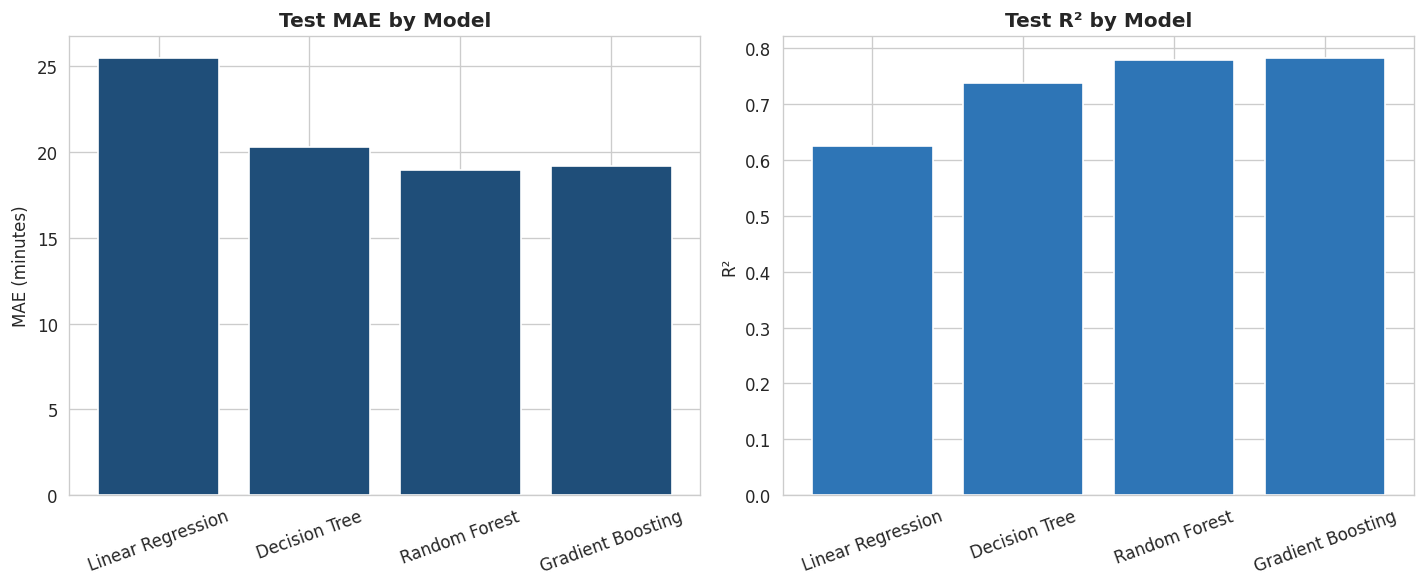

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(results_df['Model'], results_df['MAE'], color="#1F4E79")
axes[0].set_title('Test MAE by Model', fontweight='bold')
axes[0].set_ylabel('MAE (minutes)')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(results_df['Model'], results_df['R2'], color="#2E75B6")
axes[1].set_title('Test R² by Model', fontweight='bold')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('chart_model_comparison.png', dpi=200)
plt.show()

In [7]:
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 14, 18],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV MAE:", -grid.best_score_)

best_model = grid.best_estimator_
pred_tuned = best_model.predict(X_test)
print("Tuned Test MAE:", mean_absolute_error(y_test, pred_tuned))
print("Tuned Test RMSE:", np.sqrt(mean_squared_error(y_test, pred_tuned)))
print("Tuned Test R2:", r2_score(y_test, pred_tuned))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'max_depth': 14, 'min_samples_leaf': 4, 'n_estimators': 200}
Best CV MAE: 18.52323177015767
Tuned Test MAE: 18.924189256095712
Tuned Test RMSE: 24.692262785091046
Tuned Test R2: 0.7811203186541315


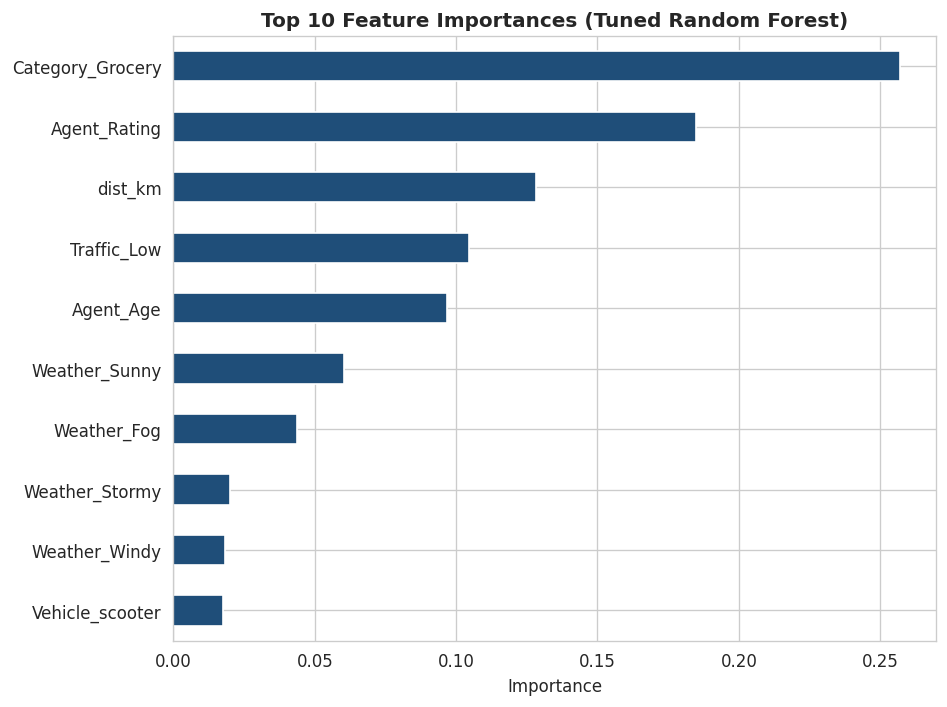

Category_Grocery    0.256904
Agent_Rating        0.185010
dist_km             0.128128
Traffic_Low         0.104523
Agent_Age           0.096825
Weather_Sunny       0.060191
Weather_Fog         0.043883
Weather_Stormy      0.019933
Weather_Windy       0.018282
Vehicle_scooter     0.017626
dtype: float64


In [8]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(10)[::-1].plot(kind='barh', color="#1F4E79")
plt.title('Top 10 Feature Importances (Tuned Random Forest)', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('chart_feature_importance.png', dpi=200)
plt.show()

print(importances.head(10))

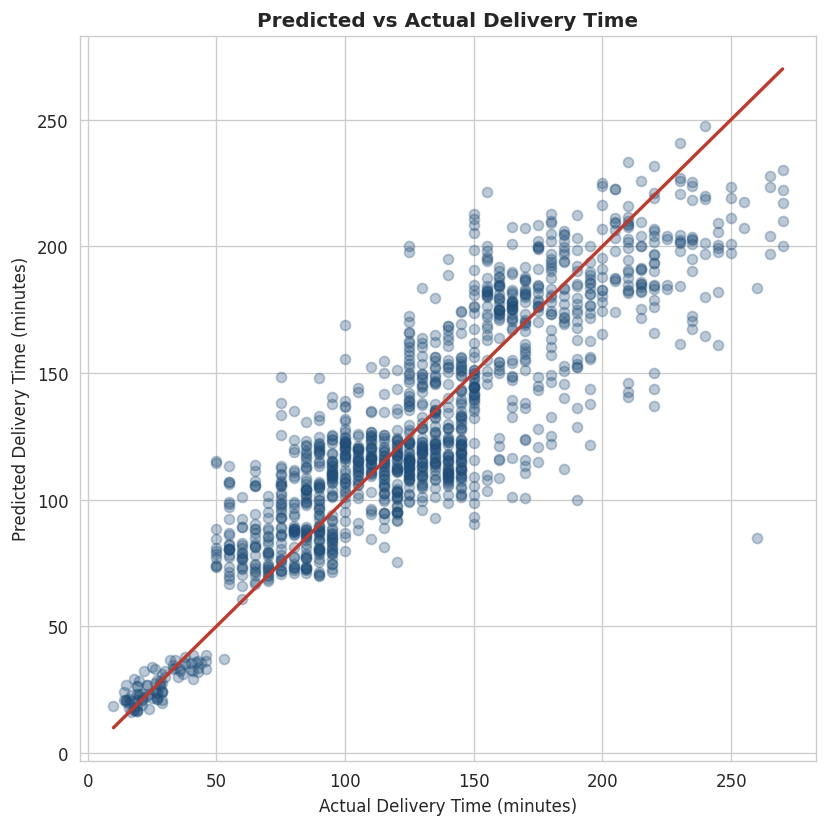

In [9]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred_tuned, alpha=0.3, color="#1F4E79")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="#C0392B", lw=2)
plt.xlabel('Actual Delivery Time (minutes)')
plt.ylabel('Predicted Delivery Time (minutes)')
plt.title('Predicted vs Actual Delivery Time', fontweight='bold')
plt.tight_layout()
plt.savefig('chart_predicted_vs_actual.png', dpi=200)
plt.show()

In [10]:
SLA = 120  # minutes

df_test = X_test.copy()
df_test['actual'] = y_test.values
df_test['predicted'] = pred_tuned
df_test['predicted_breach'] = df_test['predicted'] > SLA
df_test['actual_breach'] = df_test['actual'] > SLA

accuracy = (df_test['predicted_breach'] == df_test['actual_breach']).mean()
print(f"SLA-breach flagging accuracy: {accuracy*100:.1f}%")
print(f"Orders flagged as high risk: {df_test['predicted_breach'].sum()} of {len(df_test)}")

SLA-breach flagging accuracy: 82.0%
Orders flagged as high risk: 669 of 1376


In [11]:
from scipy.optimize import linprog

# Small simulation: assign a batch of orders to available agents to minimize total predicted time
np.random.seed(42)
n_orders = 8
n_agents = 4
capacity = 3  # max orders per agent

# Simulate predicted delivery time (minutes) for each order-agent pair
# In practice this would come from the trained model run per agent profile
cost = np.random.randint(60, 200, size=(n_agents, n_orders))
print("Predicted time matrix (agents x orders):\n", cost)

# Flatten decision variables: x[i,j] = 1 if agent i delivers order j
n_vars = n_agents * n_orders
c = cost.flatten()  # minimize total predicted time

# Constraint 1: each order assigned to exactly one agent
A_eq = []
b_eq = []
for j in range(n_orders):
    row = np.zeros(n_vars)
    for i in range(n_agents):
        row[i * n_orders + j] = 1
    A_eq.append(row)
    b_eq.append(1)

# Constraint 2: each agent handles at most `capacity` orders
A_ub = []
b_ub = []
for i in range(n_agents):
    row = np.zeros(n_vars)
    for j in range(n_orders):
        row[i * n_orders + j] = 1
    A_ub.append(row)
    b_ub.append(capacity)

bounds = [(0, 1) for _ in range(n_vars)]

result = linprog(c, A_eq=A_eq, b_eq=b_eq, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

assignment = result.x.reshape(n_agents, n_orders).round().astype(int)
print("\nOptimal assignment (rows=agents, cols=orders):\n", assignment)
print("\nTotal minimized predicted delivery time:", result.fun)

for i in range(n_agents):
    assigned_orders = np.where(assignment[i] == 1)[0]
    print(f"Agent {i+1} -> Orders {list(assigned_orders)}  (total time: {cost[i, assigned_orders].sum()} min)")

Predicted time matrix (agents x orders):
 [[162 152  74 166 131  80 162 181]
 [134 147 176 159 163 190 112  61]
 [147  97 189  80 117  81 148 108]
 [118  74 110 167 114 123 190 110]]

Optimal assignment (rows=agents, cols=orders):
 [[0 0 1 0 0 1 0 0]
 [0 0 0 0 0 0 1 1]
 [0 0 0 1 0 0 0 0]
 [1 1 0 0 1 0 0 0]]

Total minimized predicted delivery time: 713.0
Agent 1 -> Orders [np.int64(2), np.int64(5)]  (total time: 154 min)
Agent 2 -> Orders [np.int64(6), np.int64(7)]  (total time: 173 min)
Agent 3 -> Orders [np.int64(3)]  (total time: 80 min)
Agent 4 -> Orders [np.int64(0), np.int64(1), np.int64(4)]  (total time: 306 min)


Naive round-robin total time: 1244 min
Optimized assignment total time: 713 min
Improvement: 531 min (42.7% reduction)


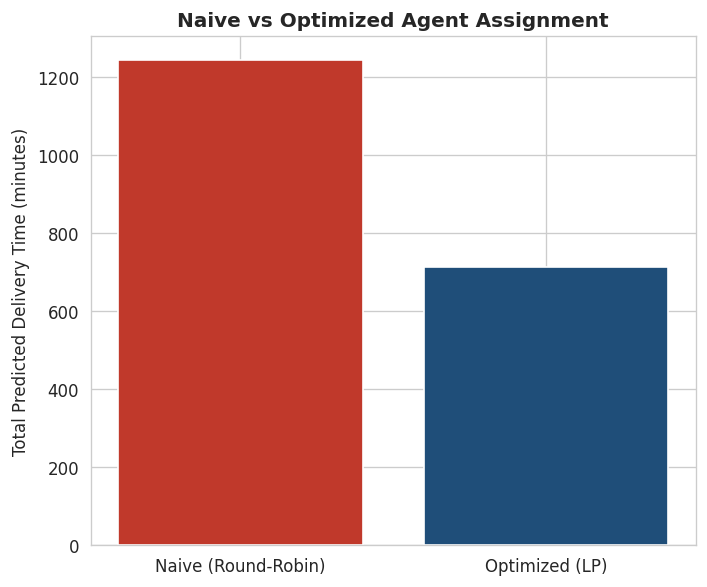

In [12]:
# Naive baseline: assign orders to agents in simple round-robin order
naive_total = 0
agent_load = [0] * n_agents
naive_assignment = {i: [] for i in range(n_agents)}
for j in range(n_orders):
    i = j % n_agents
    naive_assignment[i].append(j)
    naive_total += cost[i, j]

optimized_total = result.fun

print(f"Naive round-robin total time: {naive_total} min")
print(f"Optimized assignment total time: {optimized_total:.0f} min")
print(f"Improvement: {naive_total - optimized_total:.0f} min "
      f"({(1 - optimized_total/naive_total)*100:.1f}% reduction)")

plt.figure(figsize=(6, 5))
plt.bar(['Naive (Round-Robin)', 'Optimized (LP)'], [naive_total, optimized_total],
        color=["#C0392B", "#1F4E79"])
plt.ylabel('Total Predicted Delivery Time (minutes)')
plt.title('Naive vs Optimized Agent Assignment', fontweight='bold')
plt.tight_layout()
plt.savefig('chart_optimization_comparison.png', dpi=200)
plt.show()

In [13]:
summary = pd.DataFrame({
    'Model': results_df['Model'],
    'Test_MAE': results_df['MAE'].round(2),
    'Test_RMSE': results_df['RMSE'].round(2),
    'Test_R2': results_df['R2'].round(3)
})
print(summary)

summary.to_csv('model_comparison_results.csv', index=False)

from google.colab import files
import os
for f in sorted(os.listdir('.')):
    if f.startswith('chart') and f.endswith('.png'):
        files.download(f)
files.download('model_comparison_results.csv')

               Model  Test_MAE  Test_RMSE  Test_R2
0  Linear Regression     25.50      32.28    0.626
1      Decision Tree     20.32      27.02    0.738
2      Random Forest     18.94      24.75    0.780
3  Gradient Boosting     19.18      24.58    0.783


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>